In [54]:
import pandas as pd
import numpy as np
from faker import Faker

fake = Faker()
np.random.seed(42)

# ─────────────────────────────────────────────────────────────────
# STEP 1: Define persona archetypes top-down from Rogers + TAM theory
# Wide separation is deliberate — this is what makes K-Means find
# clean clusters. The spreads (std) are realistic within each type.
# ─────────────────────────────────────────────────────────────────

PERSONA_SPECS = {
    "Tech Pioneer": {
        "n": 50,
        # Attitudinal base (IBM-calibrated ranges, wide separation)
        "satisfaction":         (8.5, 0.7),   # 1–10
        "productivity_base":    (0.88, 0.06),  # 0–1
        "resistance_propensity":(0.12, 0.07),  # 0–1  ← deliberately LOW
        "training_times_yr":    (5.1,  0.9),   # 0–6
        "churn_risk_p":          0.05,          # probability of churn flag
        # Digital dexterity — the 5th clustering feature
        "digital_dexterity":    (8.8, 0.6),   # 1–10  ← deliberately HIGH
        # M365 signals
        "email_vol_daily":      (52,  9.0),
        "meetings_per_week":    (11,  2.5),
        "teams_msg_daily":      (38,  8.0),
        # ITSM
        "tickets_lam":           0.8,           # Poisson λ per month
        "resolution_hrs":       (2.8, 1.2),
        "reopened_beta":        (1.0, 14.0),   # Beta(a,b) → low reopen rate
        # DEX
        "crash_beta":           (1.0, 18.0),   # Beta → very low crash rate
        "load_time":            (1.8, 0.6),
        "session_min":          (55,  14.0),
        # Survey
        "enps":                 (72,  13.0),
        "dex_feedback":         (8.4,  0.8),
        "pulse_sat":            (4.2,  0.5),
        # SSO
        "logins_lam":            6.2,
        "failed_lam":            0.4,
        "activation_beta":      (9.0,  1.0),   # Beta → ~90% activation
        # LMS
        "lms_comp":             (0.91, 0.06),
        "assess_score":         (86,   8.0),
        "complete_hrs":         (3.1,  1.0),
        # Ticket category weights
        "cat_probs": [0.10, 0.20, 0.15, 0.10, 0.10, 0.25, 0.10],
    },

    "Power User": {
        "n": 150,
        "satisfaction":         (7.8, 0.9),
        "productivity_base":    (0.82, 0.07),
        "resistance_propensity":(0.22, 0.09),
        "training_times_yr":    (4.4,  1.0),
        "churn_risk_p":          0.08,
        "digital_dexterity":    (7.9, 0.7),
        "email_vol_daily":      (61,  11.0),
        "meetings_per_week":    (13,   3.0),
        "teams_msg_daily":      (45,  10.0),
        "tickets_lam":           1.1,
        "resolution_hrs":       (3.5,  1.4),
        "reopened_beta":        (1.1, 12.0),
        "crash_beta":           (1.1, 16.0),
        "load_time":            (2.1,  0.7),
        "session_min":          (62,  16.0),
        "enps":                 (58,  15.0),
        "dex_feedback":         (7.6,  1.0),
        "pulse_sat":            (3.9,  0.6),
        "logins_lam":            5.8,
        "failed_lam":            0.6,
        "activation_beta":      (8.0,  1.5),
        "lms_comp":             (0.84, 0.08),
        "assess_score":         (82,  10.0),
        "complete_hrs":         (3.8,  1.2),
        "cat_probs": [0.08, 0.25, 0.12, 0.15, 0.08, 0.22, 0.10],
    },

    "Pragmatic Adopter": {
        "n": 300,
        "satisfaction":         (5.8, 1.1),
        "productivity_base":    (0.65, 0.09),
        "resistance_propensity":(0.45, 0.10),   # deliberate mid-point
        "training_times_yr":    (3.0,  1.1),
        "churn_risk_p":          0.16,
        "digital_dexterity":    (5.5, 0.9),     # deliberate mid-point
        "email_vol_daily":      (36,   8.0),
        "meetings_per_week":    (8,    2.0),
        "teams_msg_daily":      (22,   6.0),
        "tickets_lam":           2.1,
        "resolution_hrs":       (5.8,  2.0),
        "reopened_beta":        (1.4, 10.0),
        "crash_beta":           (1.5, 12.0),
        "load_time":            (3.2,  1.1),
        "session_min":          (42,  18.0),
        "enps":                 (28,  20.0),
        "dex_feedback":         (5.8,  1.4),
        "pulse_sat":            (3.2,  0.8),
        "logins_lam":            4.1,
        "failed_lam":            1.1,
        "activation_beta":      (5.5,  3.5),
        "lms_comp":             (0.64, 0.12),
        "assess_score":         (72,  12.0),
        "complete_hrs":         (5.8,  1.8),
        "cat_probs": [0.20, 0.18, 0.18, 0.14, 0.12, 0.12, 0.06],
    },

    "Remote-First Worker": {
        "n": 200,
        "satisfaction":         (6.5, 1.0),
        "productivity_base":    (0.68, 0.09),
        "resistance_propensity":(0.52, 0.10),   # slightly above Pragmatic
        "training_times_yr":    (3.4,  1.1),
        "churn_risk_p":          0.18,
        "digital_dexterity":    (6.1, 0.9),     # between Pragmatic and Power
        "email_vol_daily":      (31,   7.0),
        "meetings_per_week":    (9,    2.2),
        "teams_msg_daily":      (34,   9.0),    # high — async/remote collab
        "tickets_lam":           2.6,
        "resolution_hrs":       (6.5,  2.2),
        "reopened_beta":        (1.5,  9.5),
        "crash_beta":           (1.6, 10.0),
        "load_time":            (4.0,  1.6),    # higher — remote network latency
        "session_min":          (38,  16.0),
        "enps":                 (38,  19.0),
        "dex_feedback":         (6.2,  1.3),
        "pulse_sat":            (3.5,  0.8),
        "logins_lam":            4.8,
        "failed_lam":            1.4,
        "activation_beta":      (5.0,  3.0),
        "lms_comp":             (0.71, 0.11),
        "assess_score":         (75,  11.0),
        "complete_hrs":         (5.2,  1.6),
        "cat_probs": [0.15, 0.14, 0.28, 0.12, 0.18, 0.10, 0.03],
    },

    "Reluctant User": {
        "n": 300,
        "satisfaction":         (3.2, 1.0),    # ← deliberately LOW
        "productivity_base":    (0.48, 0.09),  # ← deliberately LOW
        "resistance_propensity":(0.80, 0.09),  # ← deliberately HIGH
        "training_times_yr":    (1.4,  0.9),
        "churn_risk_p":          0.32,
        "digital_dexterity":    (3.1, 0.8),   # ← deliberately LOW
        "email_vol_daily":      (19,   6.0),
        "meetings_per_week":    (5,    1.8),
        "teams_msg_daily":      (11,   4.0),
        "tickets_lam":           5.2,          # ← deliberately HIGH
        "resolution_hrs":       (9.5,  3.0),
        "reopened_beta":        (2.5,  8.0),   # higher reopen rate
        "crash_beta":           (2.2,  8.0),   # higher crash rate
        "load_time":            (5.1,  1.8),
        "session_min":          (28,  12.0),
        "enps":                 (-18,  26.0),  # ← negative eNPS
        "dex_feedback":         (3.1,  1.5),
        "pulse_sat":            (2.2,  0.9),
        "logins_lam":            2.8,
        "failed_lam":            2.4,          # ← high failed logins
        "activation_beta":      (2.5,  4.5),  # ← ~35% activation
        "lms_comp":             (0.36, 0.14),
        "assess_score":         (58,  15.0),
        "complete_hrs":         (8.2,  2.4),
        "cat_probs": [0.28, 0.12, 0.16, 0.22, 0.14, 0.06, 0.02],
    },
}

CATEGORIES = ['Password Reset', 'Software Install', 'VPN / Network',
              'App Crash', 'Hardware', 'Access / Permissions', 'Training Request']

In [55]:
# ─────────────────────────────────────────────────────────────────
# STEP 2: Generate rows persona-by-persona
# ─────────────────────────────────────────────────────────────────

rows = []

for persona, p in PERSONA_SPECS.items():
    n = p["n"]

    for _ in range(n):
        # Identity
        emp_id = str(fake.uuid4())

        # Attitudinal base
        sat       = np.clip(np.random.normal(*p["satisfaction"]),         1, 10)
        prod      = np.clip(np.random.normal(*p["productivity_base"]),    0, 1)
        resist    = np.clip(np.random.normal(*p["resistance_propensity"]),0, 1)
        train_yr  = int(np.clip(np.random.normal(*p["training_times_yr"]),0, 6))
        churn     = int(np.random.random() < p["churn_risk_p"])

        # Digital dexterity (5th clustering feature)
        dex       = np.clip(np.random.normal(*p["digital_dexterity"]), 1, 10)

        # M365
        email     = np.clip(np.random.normal(*p["email_vol_daily"]),   2, 150)
        meetings  = np.clip(np.random.normal(*p["meetings_per_week"]), 0, 30)
        teams_msg = np.clip(np.random.normal(*p["teams_msg_daily"]),   0, 120)
        collab    = np.clip(
            email/150*0.3 + meetings/30*0.4 + teams_msg/120*0.3, 0, 1)

        # ITSM
        tickets   = np.random.poisson(p["tickets_lam"])
        res_hrs   = np.clip(np.random.normal(*p["resolution_hrs"]),   0.5, 72)
        reopen    = np.clip(np.random.beta(*p["reopened_beta"]),      0, 1)
        cat       = np.random.choice(CATEGORIES, p=p["cat_probs"])
        supp_dep  = np.clip(tickets / 10.0, 0, 1)
        frustrate = np.clip(res_hrs/72*0.6 + reopen*0.4, 0, 1)

        # DEX
        crash     = np.clip(np.random.beta(*p["crash_beta"]),         0, 1)
        load_t    = np.clip(np.random.normal(*p["load_time"]),        0.5, 20)
        session   = np.clip(np.random.normal(*p["session_min"]),      5, 150)
        friction  = np.clip(frustrate*0.5 + crash*0.3 + load_t/20*0.2, 0, 1)

        # Survey
        enps      = np.clip(np.random.normal(*p["enps"]),            -100, 100)
        dex_fb    = np.clip(np.random.normal(*p["dex_feedback"]),     1, 10)
        pulse     = np.clip(np.random.normal(*p["pulse_sat"]),        1, 5)

        # SSO
        logins    = np.random.poisson(p["logins_lam"])
        failed    = np.random.poisson(p["failed_lam"])
        activ     = np.clip(np.random.beta(*p["activation_beta"]),    0, 1)

        # LMS
        lms       = np.clip(np.random.normal(*p["lms_comp"]),         0, 1)
        assess    = np.clip(np.random.normal(*p["assess_score"]),      0, 100)
        comp_hrs  = np.clip(np.random.normal(*p["complete_hrs"]),      0.5, 25)

        # Final digital_dexterity composite (refine with all signals)
        dex_final = np.clip(
            dex           * 0.40 +
            activ * 10    * 0.25 +
            lms   * 10    * 0.20 +
            (1-crash)* 10 * 0.10 +
            dex_fb        * 0.05,
            1, 10
        )

        rows.append({
            "employee_id":        emp_id,
            "persona":            persona,
            "satisfaction_score": round(sat, 3),
            "productivity_baseline": round(prod, 3),
            "resistance_propensity": round(resist, 3),
            "training_times_yr":  train_yr,
            "churn_risk_flag":    churn,
            "digital_dexterity":  round(dex_final, 3),
            "email_vol_daily":    round(email, 2),
            "meetings_per_week":  round(meetings, 2),
            "teams_msg_daily":    round(teams_msg, 2),
            "collab_density":     round(collab, 3),
            "tickets_per_month":  tickets,
            "ticket_category":    cat,
            "resolution_hrs":     round(res_hrs, 2),
            "reopened_rate":      round(reopen, 3),
            "support_dependency": round(supp_dep, 3),
            "frustration_level":  round(frustrate, 3),
            "app_crash_rate":     round(crash, 3),
            "avg_load_time_sec":  round(load_t, 2),
            "session_duration_min": round(session, 1),
            "friction_level":     round(friction, 3),
            "enps_score":         round(enps, 1),
            "dex_feedback":       round(dex_fb, 2),
            "pulse_sat":          round(pulse, 2),
            "logins_per_day":     logins,
            "failed_logins_wk":   failed,
            "app_activation_rt":  round(activ, 3),
            "lms_completion":     round(lms, 3),
            "assessment_score":   round(assess, 1),
            "time_to_complete_hr": round(comp_hrs, 2),
            "is_amplifier":       0,   # will be set in Layer 2 Step 4
        })

df = pd.DataFrame(rows)
print(f"Generated: {df.shape}")
print(df['persona'].value_counts())

Generated: (1000, 32)
persona
Pragmatic Adopter      300
Reluctant User         300
Remote-First Worker    200
Power User             150
Tech Pioneer            50
Name: count, dtype: int64


In [56]:
# ─────────────────────────────────────────────────────────────────
# STEP 3: Validate benchmark recovery immediately
# ─────────────────────────────────────────────────────────────────

print("\n=== BENCHMARK RECOVERY ===")
print(f"eNPS:            {df['enps_score'].mean():.1f}      (target ~+22)")
print(f"Tickets/month:   {df['tickets_per_month'].mean():.2f}   (target ~2.4)")
print(f"App activation:  {df['app_activation_rt'].mean():.1%}   (target ~61%)")
print(f"LMS completion:  {df['lms_completion'].mean():.1%}   (target ~65%)")
print(f"Email/day:       {df['email_vol_daily'].mean():.1f}     (target ~40)")

print("\n=== DEXTERITY BY PERSONA ===")
print(df.groupby('persona')['digital_dexterity'].agg(['mean','std']).round(2))

print("\n=== RESISTANCE BY PERSONA ===")
print(df.groupby('persona')['resistance_propensity'].agg(['mean','std']).round(2))


=== BENCHMARK RECOVERY ===
eNPS:            23.6      (target ~+22)
Tickets/month:   2.91   (target ~2.4)
App activation:  58.7%   (target ~61%)
LMS completion:  61.2%   (target ~65%)
Email/day:       34.5     (target ~40)

=== DEXTERITY BY PERSONA ===
                     mean   std
persona                        
Power User           8.15  0.45
Pragmatic Adopter    6.26  0.63
Reluctant User       3.77  0.59
Remote-First Worker  6.60  0.59
Tech Pioneer         9.00  0.36

=== RESISTANCE BY PERSONA ===
                     mean   std
persona                        
Power User           0.22  0.09
Pragmatic Adopter    0.44  0.10
Reluctant User       0.80  0.09
Remote-First Worker  0.51  0.10
Tech Pioneer         0.11  0.08


In [57]:
# ─────────────────────────────────────────────────────────────────
# STEP 4: Run clustering to CONFIRM structure — not discover it
# Expected silhouette: 0.55–0.70 (much better than before)
# ─────────────────────────────────────────────────────────────────

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

CLUSTER_FEATURES = [
    'satisfaction_score', 'productivity_baseline',
    'resistance_propensity', 'training_times_yr', 'digital_dexterity'
]

scaler = StandardScaler()
X = scaler.fit_transform(df[CLUSTER_FEATURES])

# Run for k=2..7 to confirm k=5 is the best
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=30)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    print(f"k={k}  Silhouette: {sil:.4f}")

# Fit k=5 and assign cluster labels
km5 = KMeans(n_clusters=5, random_state=42, n_init=30)
df['cluster'] = km5.fit_predict(X)

# Map cluster IDs to persona names by inspecting centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(km5.cluster_centers_),
    columns=CLUSTER_FEATURES
)
print("\nCentroid table:")
print(centroids.sort_values('resistance_propensity').round(2))

# At this point you should see 5 clearly distinct centroids.
# Map cluster IDs to persona names manually based on centroid inspection.
# The cluster with lowest resistance + highest dexterity = Tech Pioneer, etc.
# IMPORTANT: your mapping will depend on which cluster ID K-Means assigned —
# inspect the centroid table and map accordingly.

# Example mapping (yours will differ — read your centroids):
# CLUSTER_TO_PERSONA = { 0: 'Tech Pioneer', 1: 'Power User', ... }
# df['cluster_label'] = df['cluster'].map(CLUSTER_TO_PERSONA)

# Verify cluster label matches persona label
# (they should agree >90% of the time if generation is correct)
# print(pd.crosstab(df['persona'], df['cluster_label']))

k=2  Silhouette: 0.4983
k=3  Silhouette: 0.4434
k=4  Silhouette: 0.3462
k=5  Silhouette: 0.3254
k=6  Silhouette: 0.2285
k=7  Silhouette: 0.2116

Centroid table:
   satisfaction_score  productivity_baseline  resistance_propensity  \
2                7.97                   0.83                   0.19   
4                5.86                   0.62                   0.45   
3                5.73                   0.60                   0.47   
0                6.61                   0.75                   0.49   
1                3.24                   0.47                   0.80   

   training_times_yr  digital_dexterity  
2               4.16               8.38  
4               1.53               6.33  
3               3.49               6.26  
0               3.25               6.65  
1               1.01               3.78  


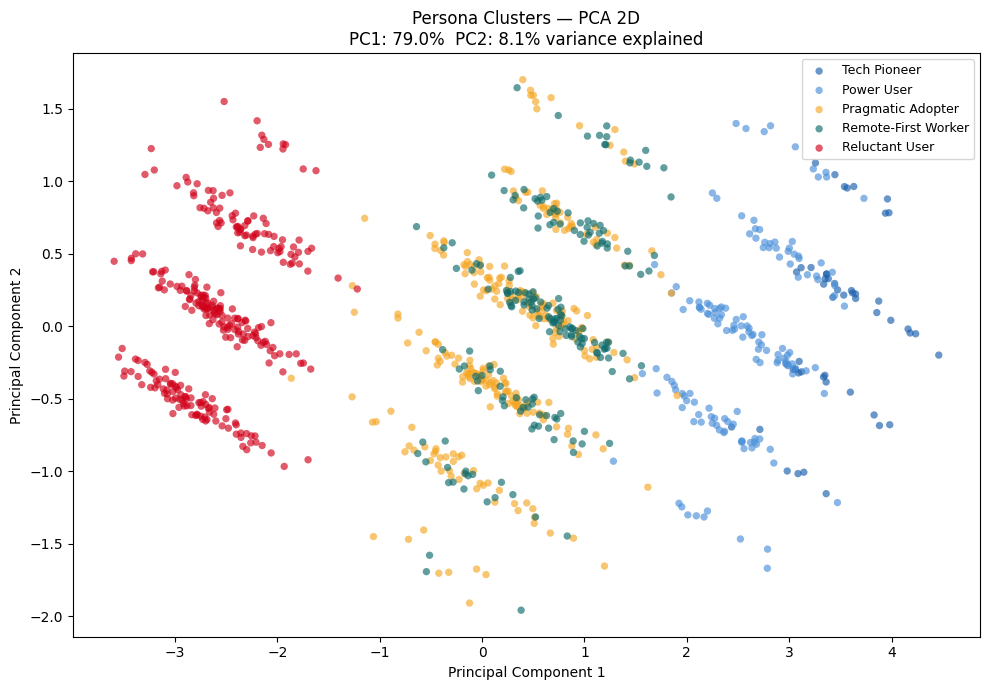

In [58]:
# ─────────────────────────────────────────────────────────────────
# STEP 5: PCA visualisation — should show 5 clean separated clouds
# ─────────────────────────────────────────────────────────────────

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

colors = {
    'Tech Pioneer':        '#1B5FAD',
    'Power User':          '#4A90D9',
    'Pragmatic Adopter':   '#F5A623',
    'Remote-First Worker': '#0E6B6B',
    'Reluctant User':      '#D0021B',
}

plt.figure(figsize=(10, 7))
for persona, color in colors.items():
    mask = df['persona'] == persona
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=color, label=persona, alpha=0.65, s=28, edgecolors='none')

plt.legend(fontsize=9)
plt.title(f'Persona Clusters — PCA 2D\n'
          f'PC1: {pca.explained_variance_ratio_[0]:.1%}  '
          f'PC2: {pca.explained_variance_ratio_[1]:.1%} variance explained')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.savefig('cluster_validation.png', dpi=150)
plt.show()

FUCKKK!! STILL NOT GOOD ENOUGH

# FIXING IT NOW.